In [1]:
import os

folder = "/kaggle/input/datasets/azalhowaide/iot-dataset-for-intrusion-detection-systems-ids"
for root, dirs, files in os.walk(folder):
    for f in files:
        print(os.path.join(root, f))

/kaggle/input/datasets/azalhowaide/iot-dataset-for-intrusion-detection-systems-ids/BotNeTIoT-L01_label_NoDuplicates.csv
/kaggle/input/datasets/azalhowaide/iot-dataset-for-intrusion-detection-systems-ids/BoTNeTIoT-L01-v2.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (10, 6)

In [3]:
df = pd.read_csv("/kaggle/input/datasets/azalhowaide/iot-dataset-for-intrusion-detection-systems-ids/BoTNeTIoT-L01-v2.csv")

# Match the Spark job: dots are struct access in Spark, so HH_L0.1_std -> HH_L0_1_std.
df = df.rename(columns=lambda c: c.replace(".", "_"))

before = df.shape[0]
print(f"Initial row count: {before}")
df.shape

Initial row count: 7062606


(7062606, 27)

In [4]:
print(df["label"].value_counts())

# with percentages
print(df["label"].value_counts(normalize=True) * 100)

label
0    6506674
1     555932
Name: count, dtype: int64
label
0    92.128515
1     7.871485
Name: proportion, dtype: float64


In [4]:
df.head()

,MI_dir_L0_1_weight,MI_dir_L0_1_mean,MI_dir_L0_1_variance,H_L0_1_weight,H_L0_1_mean,H_L0_1_variance,HH_L0_1_weight,HH_L0_1_mean,HH_L0_1_std,HH_L0_1_magnitude,...,HpHp_L0_1_mean,HpHp_L0_1_std,HpHp_L0_1_magnitude,HpHp_L0_1_radius,HpHp_L0_1_covariance,HpHp_L0_1_pcc,Device_Name,Attack,Attack_subType,label
0,1.000000,98.000000,0.000000e+00,1.000000,98.000000,0.000000e+00,1.00000,98.0,0.000000e+00,98.000000,...,98.0,0.000000,98.000000,0.000000e+00,0.0,0.0,Danmini_Doorbell,gafgyt,combo,0
1,1.931640,98.000000,1.818989e-12,1.931640,98.000000,1.818989e-12,1.93164,98.0,1.348699e-06,138.592929,...,98.0,0.000001,138.592929,1.818989e-12,0.0,0.0,Danmini_Doorbell,gafgyt,combo,0
2,2.904273,86.981750,2.311822e+02,2.904273,86.981750,2.311822e+02,1.00000,66.0,0.000000e+00,114.856432,...,66.0,0.000000,114.856432,0.000000e+00,0.0,0.0,Danmini_Doorbell,gafgyt,combo,0
3,3.902546,83.655268,2.040614e+02,3.902546,83.655268,2.040614e+02,1.00000,74.0,0.000000e+00,74.000000,...,74.0,0.000000,74.000000,0.000000e+00,0.0,0.0,Danmini_Doorbell,gafgyt,combo,0
4,4.902545,81.685828,1.775746e+02,4.902545,81.685828,1.775746e+02,2.00000,74.0,9.536743e-07,74.000000,...,74.0,0.000000,74.000000,0.000000e+00,0.0,0.0,Danmini_Doorbell,gafgyt,combo,0


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7062606 entries, 0 to 7062605
Data columns (total 27 columns):
 #   Column                Dtype  
---  ------                -----  
 0   MI_dir_L0_1_weight    float64
 1   MI_dir_L0_1_mean      float64
 2   MI_dir_L0_1_variance  float64
 3   H_L0_1_weight         float64
 4   H_L0_1_mean           float64
 5   H_L0_1_variance       float64
 6   HH_L0_1_weight        float64
 7   HH_L0_1_mean          float64
 8   HH_L0_1_std           float64
 9   HH_L0_1_magnitude     float64
 10  HH_L0_1_radius        float64
 11  HH_L0_1_covariance    float64
 12  HH_L0_1_pcc           float64
 13  HH_jit_L0_1_weight    float64
 14  HH_jit_L0_1_mean      float64
 15  HH_jit_L0_1_variance  float64
 16  HpHp_L0_1_weight      float64
 17  HpHp_L0_1_mean        float64
 18  HpHp_L0_1_std         float64
 19  HpHp_L0_1_magnitude   float64
 20  HpHp_L0_1_radius      float64
 21  HpHp_L0_1_covariance  float64
 22  HpHp_L0_1_pcc         float64
 23  Device_

In [6]:
df.isnull().sum()

MI_dir_L0_1_weight      0
MI_dir_L0_1_mean        0
MI_dir_L0_1_variance    0
H_L0_1_weight           0
H_L0_1_mean             0
H_L0_1_variance         0
HH_L0_1_weight          0
HH_L0_1_mean            0
HH_L0_1_std             0
HH_L0_1_magnitude       0
HH_L0_1_radius          0
HH_L0_1_covariance      0
HH_L0_1_pcc             0
HH_jit_L0_1_weight      0
HH_jit_L0_1_mean        0
HH_jit_L0_1_variance    0
HpHp_L0_1_weight        0
HpHp_L0_1_mean          0
HpHp_L0_1_std           0
HpHp_L0_1_magnitude     0
HpHp_L0_1_radius        0
HpHp_L0_1_covariance    0
HpHp_L0_1_pcc           0
Device_Name             0
Attack                  0
Attack_subType          0
label                   0
dtype: int64

In [7]:
df = df.drop_duplicates().reset_index(drop=True)
after = df.shape[0]
print(f"Deduplicated: {before} -> {after} rows ({before - after} removed).")

Deduplicated: 7062606 -> 6440947 rows (621659 removed).


## 2. Choose the held-out devices *before* fitting anything

The log shifts and IQR bounds below are fitted statistics. Computing them over the whole
frame and splitting afterwards lets test-device rows influence the transform applied to
training data - a leak, and one the streaming job could never reproduce, since it must
cap live records using bounds derived from history alone.

Selecting the split here costs nothing: it depends only on device row counts and label
counts, neither of which the transforms touch. **The chosen devices are identical to
before**, so results stay comparable to the earlier run.

In [8]:
from itertools import combinations

# Split configuration - the single source of truth; section 10 defers to these.
TEST_ROW_FRACTION = 0.20
MIN_TEST_NORMAL = 30_000

# Polarity, read off the Attack column while it is still present.
crosstab = pd.crosstab(df["Attack"], df["label"])
NORMAL_LABEL = int(crosstab.loc["Normal"].idxmax())
ATTACK_LABEL = int(1 - NORMAL_LABEL)
df["is_attack"] = (df["label"] == ATTACK_LABEL).astype("int8")
print(f"ATTACK_LABEL = {ATTACK_LABEL}   NORMAL_LABEL = {NORMAL_LABEL}")


def choose_test_devices(summary, target_frac=TEST_ROW_FRACTION, min_test_normal=MIN_TEST_NORMAL):
    """Smallest-error device subset that keeps both classes on both sides."""
    devices = list(summary.index)
    total = int(summary["rows"].sum())

    if len(devices) > 15:
        raise RuntimeError(
            f"{len(devices)} devices - exhaustive search over 2^n subsets is too slow. "
            "Switch to GroupShuffleSplit with a validity retry loop."
        )

    best = None
    for r in range(1, len(devices)):
        for combo in combinations(devices, r):
            in_test = summary.index.isin(combo)
            test, train = summary[in_test], summary[~in_test]
            if min(test["n_attack"].sum(), test["n_normal"].sum(),
                   train["n_attack"].sum(), train["n_normal"].sum()) == 0:
                continue                                   # a class missing from one side
            if test["n_normal"].sum() < min_test_normal:
                continue                                   # too few benign rows to measure
            err = abs(test["rows"].sum() / total - target_frac)
            if best is None or err < best[0]:
                best = (err, list(combo))

    if best is None:
        raise RuntimeError("No device subset satisfies the validity constraints.")
    return sorted(best[1])


device_summary = df.groupby("Device_Name")["is_attack"].agg(rows="size", n_attack="sum")
device_summary["n_normal"] = device_summary["rows"] - device_summary["n_attack"]

test_devices = choose_test_devices(device_summary)
train_devices = sorted(set(device_summary.index) - set(test_devices))

# Rows used to FIT the transforms. Test rows still get transformed - they just never
# contribute to computing the bounds.
fit_mask = ~df["Device_Name"].isin(test_devices)

print(f"\nTest devices  ({len(test_devices)}): {test_devices}")
print(f"Train devices ({len(train_devices)}): {train_devices}")
print(f"Fitting transforms on {fit_mask.sum():,} rows ({fit_mask.mean():.1%}); "
      f"{(~fit_mask).sum():,} test rows excluded from the fit.")

ATTACK_LABEL = 0   NORMAL_LABEL = 1

Test devices  (2): ['Ennio_Doorbell', 'Philips_B120N10_Baby_Monitor']
Train devices (7): ['Danmini_Doorbell', 'Ecobee_Thermostat', 'Provision_PT_737E_Security_Camera', 'Provision_PT_838_Security_Camera', 'Samsung_SNH_1011_N_Webcam', 'SimpleHome_XCS7_1002_WHT_Security_Camera', 'SimpleHome_XCS7_1003_WHT_Security_Camera']
Fitting transforms on 5,130,127 rows (79.6%); 1,310,820 test rows excluded from the fit.


Features statisics (skewness and outliers handling) 

In [9]:
FEATURE_COLS = [c for c in df.columns
                if c not in ("Device_Name", "Attack", "Attack_subType", "label", "is_attack")]

# Frozen list, exactly as in preprocess_batch.py. Originally derived from
# |skew| > 3, but pinned so batch and streaming apply the same transforms.
HIGH_SKEW_COLS = [
    "HH_L0_1_std", "HH_L0_1_radius", "HH_L0_1_covariance", "HH_L0_1_pcc",
    "HH_jit_L0_1_variance", "HpHp_L0_1_weight", "HpHp_L0_1_std",
    "HpHp_L0_1_radius", "HpHp_L0_1_covariance", "HpHp_L0_1_pcc",
]

In [10]:
desc = df[FEATURE_COLS].describe().T
desc["skew"] = df[FEATURE_COLS].skew()
desc["kurtosis"] = df[FEATURE_COLS].kurtosis()

computed_high_skew = desc.index[desc["skew"].abs() > 3].tolist()
print(f"Computed |skew| > 3: {sorted(computed_high_skew)}")
print(f"Pinned HIGH_SKEW_COLS: {sorted(HIGH_SKEW_COLS)}")
print(f"Drift vs. pinned list: {sorted(set(computed_high_skew) ^ set(HIGH_SKEW_COLS))}")

desc.round(4)

Computed |skew| > 3: ['HH_L0_1_covariance', 'HH_L0_1_pcc', 'HH_L0_1_radius', 'HH_L0_1_std', 'HH_jit_L0_1_variance', 'HpHp_L0_1_covariance', 'HpHp_L0_1_pcc', 'HpHp_L0_1_radius', 'HpHp_L0_1_std', 'HpHp_L0_1_weight']
Pinned HIGH_SKEW_COLS: ['HH_L0_1_covariance', 'HH_L0_1_pcc', 'HH_L0_1_radius', 'HH_L0_1_std', 'HH_jit_L0_1_variance', 'HpHp_L0_1_covariance', 'HpHp_L0_1_pcc', 'HpHp_L0_1_radius', 'HpHp_L0_1_std', 'HpHp_L0_1_weight']
Drift vs. pinned list: []


,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
MI_dir_L0_1_weight,6440947.0,3.728633e+03,2.825027e+03,1.0000,10.9495,4076.4013,6.383311e+03,8.946997e+03,-0.1880,-1.5793
MI_dir_L0_1_mean,6440947.0,1.906208e+02,1.563308e+02,60.0000,60.0968,74.5639,3.799362e+02,1.401994e+03,0.5842,-1.2520
MI_dir_L0_1_variance,6440947.0,2.109423e+04,2.675759e+04,0.0000,1.6650,281.6700,5.031722e+04,4.520011e+05,0.9414,3.5721
H_L0_1_weight,6440947.0,3.728633e+03,2.825027e+03,1.0000,10.9495,4076.4013,6.383311e+03,8.946997e+03,-0.1880,-1.5793
H_L0_1_mean,6440947.0,1.906210e+02,1.563309e+02,60.0000,60.0968,74.5639,3.799363e+02,1.401994e+03,0.5842,-1.2520
H_L0_1_variance,6440947.0,2.109425e+04,2.675758e+04,0.0000,1.6652,281.6863,5.031722e+04,4.520011e+05,0.9414,3.5721
HH_L0_1_weight,6440947.0,2.074784e+03,2.569486e+03,1.0000,1.0000,2.1937,4.356863e+03,7.944987e+03,0.7509,-0.8830
HH_L0_1_mean,6440947.0,1.904141e+02,2.121425e+02,60.0000,60.0000,73.9967,3.300000e+02,1.470000e+03,1.1537,-0.5529
HH_L0_1_std,6440947.0,4.603500e+00,2.234800e+01,0.0000,0.0000,0.0765,4.064900e+00,6.784580e+02,11.9749,190.3801
HH_L0_1_magnitude,6440947.0,1.979141e+02,2.123536e+02,60.0000,60.0000,73.9989,4.372030e+02,1.470000e+03,1.1366,-0.4030


log-transform the highly skewed features

In [11]:
# Shifts are fitted on TRAIN devices only, then applied to every row.
shifts = {}
for col in HIGH_SKEW_COLS:
    m = df.loc[fit_mask, col].min()
    shifts[col] = float(-m + 1) if m <= 0 else 0.0

    arg = df[col] + shifts[col]
    n_below = int((arg < 0).sum())
    if n_below:
        # Test-device values below anything seen in training. log1p would return NaN,
        # so they clamp to the floor - which is exactly what the streaming job must do
        # when a live record falls outside the fitted range.
        print(f"  {col}: {n_below:,} rows below the train-fitted floor, clamped")
    df[col] = np.log1p(arg.clip(lower=0.0))

print(f"Log-transformed {len(HIGH_SKEW_COLS)} columns (shifts fitted on {fit_mask.sum():,} train rows).")
df[HIGH_SKEW_COLS].skew().round(3)

  HH_L0_1_covariance: 195 rows below the train-fitted floor, clamped
  HpHp_L0_1_covariance: 112 rows below the train-fitted floor, clamped
Log-transformed 10 columns (shifts fitted on 5,130,127 train rows).


HH_L0_1_std               1.952
HH_L0_1_radius            2.174
HH_L0_1_covariance     -138.744
HH_L0_1_pcc               3.593
HH_jit_L0_1_variance      0.532
HpHp_L0_1_weight          4.081
HpHp_L0_1_std             7.062
HpHp_L0_1_radius          6.052
HpHp_L0_1_covariance   -132.439
HpHp_L0_1_pcc             0.917
dtype: float64

In [12]:
def iqr_bounds_for(series: pd.Series):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - 1.5 * iqr, q3 + 1.5 * iqr


def iqr_outlier_pct(series: pd.Series) -> float:
    lower, upper = iqr_bounds_for(series)
    return ((series < lower) | (series > upper)).mean() * 100


outlier_before = df[FEATURE_COLS].apply(iqr_outlier_pct).sort_values(ascending=False)
outlier_before.round(2).to_frame("outlier_pct").head(10)

,outlier_pct
HpHp_L0_1_weight,19.96
HH_L0_1_pcc,17.45
HpHp_L0_1_radius,15.84
HpHp_L0_1_std,15.07
HH_L0_1_covariance,5.33
HpHp_L0_1_pcc,3.67
HpHp_L0_1_covariance,3.05
HH_L0_1_radius,2.73
HH_L0_1_std,1.65
HpHp_L0_1_magnitude,0.06


Outliers Handling 

In [13]:
# Quantiles come from TRAIN devices only; the clip is applied to every row.
iqr_bounds = {}
skipped_zero_iqr = []

for col in FEATURE_COLS:
    q1, q3 = df.loc[fit_mask, col].quantile([0.25, 0.75])
    iqr = q3 - q1
    if iqr == 0:
        # Zero-inflated column: over half the rows share one value, so Q1 == Q3
        # and the bounds collapse to a single point. Capping here would clamp
        # every row to that value and leave the column constant - no information.
        skipped_zero_iqr.append(col)
        continue
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    iqr_bounds[col] = {"lower": float(lower), "upper": float(upper)}
    df[col] = df[col].clip(lower, upper)

print(f"IQR-capped {len(iqr_bounds)} feature columns (bounds fitted on {fit_mask.sum():,} train rows).")
if skipped_zero_iqr:
    print(f"Left {len(skipped_zero_iqr)} zero-IQR columns uncapped: {skipped_zero_iqr}")

n_test_clipped = int((~fit_mask).sum())
print(f"{n_test_clipped:,} test-device rows were capped with train-fitted bounds "
      f"(they contributed nothing to computing them).")

IQR-capped 16 feature columns (bounds fitted on 5,130,127 train rows).
Left 7 zero-IQR columns uncapped: ['HH_L0_1_covariance', 'HH_L0_1_pcc', 'HpHp_L0_1_weight', 'HpHp_L0_1_std', 'HpHp_L0_1_radius', 'HpHp_L0_1_covariance', 'HpHp_L0_1_pcc']
1,310,820 test-device rows were capped with train-fitted bounds (they contributed nothing to computing them).


In [14]:
import json

df.to_parquet("/kaggle/working/cleaned_full.parquet", index=False)
print(f"Full cleaned dataset written: {df.shape}")

training_df = df.drop(columns=["Attack", "Attack_subType"])
training_df.to_parquet("/kaggle/working/training_ready.parquet", index=False)
print(f"Leakage-free training dataset written: {training_df.shape}")
print(f"Training dataset columns: {list(training_df.columns)}")

# Everything the streaming job needs to replay these transforms on live records.
# The split is part of the provenance: these bounds saw train devices only, so any
# later stage must reuse this exact split or the leak comes back.
stats = {
    "high_skew_cols": HIGH_SKEW_COLS,
    "log_shifts": shifts,
    "feature_cols": FEATURE_COLS,
    "iqr_bounds": iqr_bounds,
    "fitted_on": "train_devices only",
    "split": {"train_devices": train_devices, "test_devices": test_devices},
    "label": {"attack_label": ATTACK_LABEL, "normal_label": NORMAL_LABEL},
}
with open("/kaggle/working/preprocessing_stats.json", "w") as f:
    json.dump(stats, f, indent=2)
print("Wrote preprocessing_stats.json")

training_df

Full cleaned dataset written: (6440947, 28)
Leakage-free training dataset written: (6440947, 26)
Training dataset columns: ['MI_dir_L0_1_weight', 'MI_dir_L0_1_mean', 'MI_dir_L0_1_variance', 'H_L0_1_weight', 'H_L0_1_mean', 'H_L0_1_variance', 'HH_L0_1_weight', 'HH_L0_1_mean', 'HH_L0_1_std', 'HH_L0_1_magnitude', 'HH_L0_1_radius', 'HH_L0_1_covariance', 'HH_L0_1_pcc', 'HH_jit_L0_1_weight', 'HH_jit_L0_1_mean', 'HH_jit_L0_1_variance', 'HpHp_L0_1_weight', 'HpHp_L0_1_mean', 'HpHp_L0_1_std', 'HpHp_L0_1_magnitude', 'HpHp_L0_1_radius', 'HpHp_L0_1_covariance', 'HpHp_L0_1_pcc', 'Device_Name', 'label', 'is_attack']
Wrote preprocessing_stats.json


,MI_dir_L0_1_weight,MI_dir_L0_1_mean,MI_dir_L0_1_variance,H_L0_1_weight,H_L0_1_mean,H_L0_1_variance,HH_L0_1_weight,HH_L0_1_mean,HH_L0_1_std,HH_L0_1_magnitude,...,HpHp_L0_1_weight,HpHp_L0_1_mean,HpHp_L0_1_std,HpHp_L0_1_magnitude,HpHp_L0_1_radius,HpHp_L0_1_covariance,HpHp_L0_1_pcc,Device_Name,label,is_attack
0,1.000000,98.000000,0.000000e+00,1.000000,98.000000,0.000000e+00,1.000000,98.0,0.693147,98.000000,...,0.693147,98.0,0.693147,98.000000,0.693147,10.815239,1.102181,Danmini_Doorbell,0,1
1,1.931640,98.000000,1.818989e-12,1.931640,98.000000,1.818989e-12,1.931640,98.0,0.693148,138.592929,...,1.075562,98.0,0.693148,138.592929,0.693147,10.815239,1.102181,Danmini_Doorbell,0,1
2,2.904273,86.981750,2.311822e+02,2.904273,86.981750,2.311822e+02,1.000000,66.0,0.693147,114.856432,...,0.693147,66.0,0.693147,114.856432,0.693147,10.815239,1.102181,Danmini_Doorbell,0,1
3,3.902546,83.655268,2.040614e+02,3.902546,83.655268,2.040614e+02,1.000000,74.0,0.693147,74.000000,...,0.693147,74.0,0.693147,74.000000,0.693147,10.815239,1.102181,Danmini_Doorbell,0,1
4,4.902545,81.685828,1.775746e+02,4.902545,81.685828,1.775746e+02,2.000000,74.0,0.693148,74.000000,...,0.693147,74.0,0.693147,74.000000,0.693147,10.815239,1.102181,Danmini_Doorbell,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6440942,2.801727,294.039965,8.416085e+03,2.801727,294.039965,8.416085e+03,1.214290,330.0,0.693149,431.490440,...,0.794932,330.0,0.693149,431.490440,0.693147,10.815239,1.102181,SimpleHome_XCS7_1003_WHT_Security_Camera,1,0
6440943,2.979945,215.501627,1.780468e+04,2.979945,215.501627,1.780468e+04,1.252204,60.0,0.693147,84.852814,...,0.811909,60.0,0.693147,84.852814,0.693147,10.815239,1.102181,SimpleHome_XCS7_1003_WHT_Security_Camera,1,0
6440944,1.743927,281.157093,1.080196e+04,1.743927,281.157093,1.080196e+04,1.214226,330.0,0.693147,431.490440,...,0.794903,330.0,0.693147,431.490440,0.693147,10.815239,1.102181,SimpleHome_XCS7_1003_WHT_Security_Camera,1,0
6440945,2.743925,298.957472,7.417844e+03,2.743925,298.957472,7.417844e+03,1.214226,330.0,0.693150,431.490440,...,0.794903,330.0,0.693150,431.490440,0.693147,10.815239,1.102181,SimpleHome_XCS7_1003_WHT_Security_Camera,1,0


---

# Part 2 — Model Training

Random forest on the cleaned features, evaluated under a **device-grouped split**: whole
devices go to train or test, never both. A random row split would let near-identical
traffic from one device sit on both sides and inflate the score, so this measures what
we actually care about — does the model generalise to an IoT device it has never seen.

Three things below are deliberate and easy to get wrong:

1. **Label polarity is derived, never assumed.** In this dataset `label=1` is *Normal*,
   not attack. Every metric here is computed against an explicit `is_attack` target.
2. **Only the training set is balanced.** The test set keeps its natural ratio, because
   that is the ratio a deployed model actually sees.
3. **`HH_jit_L0_1_mean` is audited.** It carries Unix-epoch values that separate the
   classes almost by themselves. Section 21 retrains without it so we can report an
   honest number rather than a contaminated one.

## 10. Training imports and configuration

In [15]:
import json
import time
from itertools import combinations
from pathlib import Path

import joblib
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    f1_score,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)

SEED = 42

# Device-grouped split: aim for ~20% of rows in the held-out devices, and refuse any
# split that leaves a class missing or the minority class too thin to measure.
TEST_ROW_FRACTION = globals().get("TEST_ROW_FRACTION", 0.20)
MIN_TEST_NORMAL = globals().get("MIN_TEST_NORMAL", 30_000)

# Training-set balancing. Capping Normal keeps the fit fast; the 2:1 ratio keeps enough
# attack variety without drowning the minority class. Test set is never touched.
NORMAL_CAP = 175_000
ATTACK_TO_NORMAL_RATIO = 2.0

N_ESTIMATORS = 200

# The suspect column, audited in section 21.
SUSPECT_FEATURE = "HH_jit_L0_1_mean"

# Kaggle paths. Point these at /output and /models to run inside the Spark container.
WORK = Path("/kaggle/working")
MODEL_DIR = WORK / "models"
PRED_DIR = WORK / "predictions"
MODEL_DIR.mkdir(parents=True, exist_ok=True)
PRED_DIR.mkdir(parents=True, exist_ok=True)

print(f"seed={SEED}  normal_cap={NORMAL_CAP:,}  ratio={ATTACK_TO_NORMAL_RATIO}:1  trees={N_ESTIMATORS}")

seed=42  normal_cap=175,000  ratio=2.0:1  trees=200


## 11. Load `training_ready`

23 numeric features + `Device_Name` (unencoded, used only for grouping) + `label`.
Runs standalone: if the preprocessing cells above are not in memory it reloads from disk.

In [16]:
try:
    training_df
except NameError:
    training_df = pd.read_parquet(WORK / "training_ready.parquet")

try:
    FEATURE_COLS
except NameError:
    FEATURE_COLS = [c for c in training_df.columns if c not in ("Device_Name", "label", "is_attack")]

print(f"training_ready: {training_df.shape[0]:,} rows x {training_df.shape[1]} cols")
print(f"{len(FEATURE_COLS)} feature columns")
print(f"{training_df['Device_Name'].nunique()} devices")

training_ready: 6,440,947 rows x 26 cols
23 feature columns
9 devices


## 12. Which label value means "attack"?

This is the single most consequential line in the notebook. `training_ready` has no
`Attack` column — it was dropped as leakage — so where the pre-drop frame is still in
memory we read the polarity straight off the `Attack` column. Otherwise we fall back to
the class balance, since attacks are the ~92% majority.

Getting this backwards does not throw an error. It silently reports every metric for the
wrong class, which is why it is derived and printed rather than hard-coded.

In [17]:
if globals().get("ATTACK_LABEL") is None:
    try:  # authoritative: read polarity off the Attack column
        crosstab = pd.crosstab(df["Attack"], df["label"])
        print("Attack x label:")
        print(crosstab, "\n")
        NORMAL_LABEL = int(crosstab.loc["Normal"].idxmax())
        ATTACK_LABEL = int(1 - NORMAL_LABEL)
        print("Polarity derived from the Attack column.")
    except (NameError, KeyError):
        counts = training_df["label"].value_counts()
        ATTACK_LABEL, NORMAL_LABEL = int(counts.idxmax()), int(counts.idxmin())
        print("Attack column unavailable - polarity inferred from class balance.")
else:
    print("Polarity already established in section 2, before the transforms were fitted.")

print(f"\nATTACK_LABEL = {ATTACK_LABEL}   NORMAL_LABEL = {NORMAL_LABEL}")

# One explicit target column: 1 = attack. Everything downstream uses this, so no reader
# has to remember that raw `label` runs the other way.
training_df["is_attack"] = (training_df["label"] == ATTACK_LABEL).astype("int8")

print(f"Attack prevalence: {training_df['is_attack'].mean():.4f}")

Polarity already established in section 2, before the transforms were fitted.

ATTACK_LABEL = 0   NORMAL_LABEL = 1
Attack prevalence: 0.9203


## 13. Device-grouped split

`GroupShuffleSplit` would respect the grouping but cannot guarantee both classes land on
both sides, nor that the held-out set has enough benign rows to measure precision on.
With only nine devices we can enumerate every subset instead and pick the valid one whose
row share sits closest to the target — deterministic, and no seed involved.

In [18]:
device_summary = (
    training_df.groupby("Device_Name")["is_attack"]
    .agg(rows="size", n_attack="sum")
)
device_summary["n_normal"] = device_summary["rows"] - device_summary["n_attack"]
device_summary["attack_pct"] = (100 * device_summary["n_attack"] / device_summary["rows"]).round(2)
device_summary.sort_values("rows", ascending=False)

,rows,n_attack,n_normal,attack_pct
Device_Name,,,,
Philips_B120N10_Baby_Monitor,1024970,859829,165141,83.89
Danmini_Doorbell,945653,905258,40395,95.73
SimpleHome_XCS7_1002_WHT_Security_Camera,797586,754802,42784,94.64
SimpleHome_XCS7_1003_WHT_Security_Camera,784641,766705,17936,97.71
Ecobee_Thermostat,771830,758719,13111,98.30
Provision_PT_838_Security_Camera,770184,676189,93995,87.80
Provision_PT_737E_Security_Camera,754308,699139,55169,92.69
Samsung_SNH_1011_N_Webcam,305925,256366,49559,83.80
Ennio_Doorbell,285850,250440,35410,87.61


In [19]:
# The split MUST match the one the transforms were fitted against, so it is reused
# rather than recomputed. Re-deriving it here would risk a silent mismatch.
if "test_devices" in globals():
    print("Reusing the device split chosen in section 2 (before any transform was fitted).")
else:
    with open(WORK / "preprocessing_stats.json") as f:
        test_devices = json.load(f)["split"]["test_devices"]
    print("Loaded the device split from preprocessing_stats.json.")

train_devices = sorted(set(device_summary.index) - set(test_devices))

train_df = training_df[training_df["Device_Name"].isin(train_devices)]
test_df = training_df[training_df["Device_Name"].isin(test_devices)]

assert not set(train_df["Device_Name"]) & set(test_df["Device_Name"]), "device leaked across the split"

print(f"\nTest devices  ({len(test_devices)}): {test_devices}")
print(f"Train devices ({len(train_devices)}): {train_devices}\n")
for name, part in (("Train", train_df), ("Test", test_df)):
    print(f"{name}: {len(part):>9,} rows   attack {part['is_attack'].mean():6.2%}   "
          f"normal {len(part) - part['is_attack'].sum():>8,}")

Reusing the device split chosen in section 2 (before any transform was fitted).

Test devices  (2): ['Ennio_Doorbell', 'Philips_B120N10_Baby_Monitor']
Train devices (7): ['Danmini_Doorbell', 'Ecobee_Thermostat', 'Provision_PT_737E_Security_Camera', 'Provision_PT_838_Security_Camera', 'Samsung_SNH_1011_N_Webcam', 'SimpleHome_XCS7_1002_WHT_Security_Camera', 'SimpleHome_XCS7_1003_WHT_Security_Camera']

Train: 5,130,127 rows   attack 93.90%   normal  312,949
Test: 1,310,820 rows   attack 84.70%   normal  200,551


## 14. Drop `Device_Name`

Its only job was grouping the split. It never becomes a model feature — leaving it in
would let the forest memorise per-device signatures instead of learning traffic behaviour,
and it would be meaningless on a device the model has never seen.

In [20]:
train_df = train_df.drop(columns=["Device_Name"])
test_df = test_df.drop(columns=["Device_Name"])
print(f"Columns now: {len(train_df.columns)} ({len(FEATURE_COLS)} features + label + is_attack)")

Columns now: 25 (23 features + label + is_attack)


## 15. Balance the training set only

Down-sample to a capped Normal subset paired with roughly double that in Attack. The cap
keeps training fast without discarding attack variety, and the 2:1 ratio leaves the model
a realistic prior that attacks are more common than benign traffic on this network.

`test_df` is never touched. Evaluating on the natural ~92/8 ratio is the entire point of
holding it out.

In [21]:
train_normal = train_df[train_df["is_attack"] == 0]
train_attack = train_df[train_df["is_attack"] == 1]

n_normal = min(len(train_normal), NORMAL_CAP)
n_attack = min(len(train_attack), int(round(n_normal * ATTACK_TO_NORMAL_RATIO)))

train_balanced = (
    pd.concat([
        train_normal.sample(n=n_normal, random_state=SEED),
        train_attack.sample(n=n_attack, random_state=SEED),
    ])
    .sample(frac=1, random_state=SEED)      # shuffle
    .reset_index(drop=True)
)

print(f"Train available: {len(train_df):>9,}  ({len(train_attack):,} attack / {len(train_normal):,} normal)")
print(f"Train balanced:  {len(train_balanced):>9,}  ({n_attack:,} attack / {n_normal:,} normal)"
      f"  = {n_attack / n_normal:.2f}:1")
print(f"Test (untouched):{len(test_df):>9,}  attack ratio {test_df['is_attack'].mean():.2%}")

Train available: 5,130,127  (4,817,178 attack / 312,949 normal)
Train balanced:    525,000  (350,000 attack / 175,000 normal)  = 2.00:1
Test (untouched):1,310,820  attack ratio 84.70%


## 16. Feature matrices

sklearn takes a plain 2D array, so selecting the 23 columns **in a fixed order** is the
whole step — no `VectorAssembler` equivalent needed. That order is saved alongside the
model in section 22; inference must reproduce it exactly or the columns silently shift.

`float32` halves memory versus `float64` at no cost to a tree ensemble, which splits on
thresholds rather than accumulating precision.

In [22]:
def matrices(train_frame, test_frame, feature_cols):
    Xtr = train_frame[feature_cols].to_numpy(dtype=np.float32)
    ytr = train_frame["is_attack"].to_numpy()
    Xte = test_frame[feature_cols].to_numpy(dtype=np.float32)
    yte = test_frame["is_attack"].to_numpy()
    return Xtr, ytr, Xte, yte


X_train, y_train, X_test, y_test = matrices(train_balanced, test_df, FEATURE_COLS)

print(f"X_train {X_train.shape}  ({X_train.nbytes / 1e6:.0f} MB)")
print(f"X_test  {X_test.shape}  ({X_test.nbytes / 1e6:.0f} MB)")

X_train (525000, 23)  (48 MB)
X_test  (1310820, 23)  (121 MB)


## 17. Train the random forest

In [23]:
def train_forest(Xtr, ytr, n_estimators=N_ESTIMATORS, seed=SEED):
    clf = RandomForestClassifier(
        n_estimators=n_estimators,
        random_state=seed,
        n_jobs=-1,
    )
    t0 = time.time()
    clf.fit(Xtr, ytr)
    print(f"Trained {n_estimators} trees on {Xtr.shape[0]:,} rows in {time.time() - t0:.1f}s")
    return clf


rf = train_forest(X_train, y_train)
print(f"Class order: {rf.classes_}   (index of attack = {list(rf.classes_).index(1)})")

Trained 200 trees on 525,000 rows in 63.0s
Class order: [0 1]   (index of attack = 1)


## 18. Evaluate on the untouched test set

**On AUC-PR.** Average precision depends on which class you call positive, and its
no-skill baseline is that class's prevalence. Attacks are ~92% of the test rows, so
AP-for-attack starts near 0.92 before the model does anything — an impressive-looking
number that means very little. The discriminating metric here is AP for the **Normal**
class, whose baseline is ~0.08. Both are printed against their baselines so neither can
be quoted out of context. ROC-AUC is shown for reference only; it is the metric that
flatters imbalanced problems.

In [24]:
def evaluate(clf, Xte, yte, title):
    """yte is is_attack: 1 = attack, 0 = normal."""
    y_pred = clf.predict(Xte)
    attack_idx = list(clf.classes_).index(1)
    p_attack = clf.predict_proba(Xte)[:, attack_idx]

    base_attack = yte.mean()
    base_normal = 1 - base_attack

    m = {
        "accuracy":  accuracy_score(yte, y_pred),
        "precision": precision_score(yte, y_pred, pos_label=1, zero_division=0),
        "recall":    recall_score(yte, y_pred, pos_label=1, zero_division=0),
        "f1":        f1_score(yte, y_pred, pos_label=1, zero_division=0),
        "ap_attack": average_precision_score(yte, p_attack),
        "ap_normal": average_precision_score(1 - yte, 1.0 - p_attack),
        "roc_auc":   roc_auc_score(yte, p_attack),
    }

    print(f"--- {title} ---")
    print(f"Accuracy                {m['accuracy']:.4f}")
    print(f"Precision (Attack)      {m['precision']:.4f}")
    print(f"Recall    (Attack)      {m['recall']:.4f}")
    print(f"F1        (Attack)      {m['f1']:.4f}")
    print(f"AUC-PR    (Normal)      {m['ap_normal']:.4f}   baseline {base_normal:.4f}   <-- minority, the honest one")
    print(f"AUC-PR    (Attack)      {m['ap_attack']:.4f}   baseline {base_attack:.4f}")
    print(f"ROC-AUC                 {m['roc_auc']:.4f}   (reference only)")
    return y_pred, p_attack, m


y_pred, p_attack, metrics_full = evaluate(rf, X_test, y_test, "All 23 features")

--- All 23 features ---
Accuracy                0.9993
Precision (Attack)      0.9993
Recall    (Attack)      0.9999
F1        (Attack)      0.9996
AUC-PR    (Normal)      1.0000   baseline 0.1530   <-- minority, the honest one
AUC-PR    (Attack)      1.0000   baseline 0.8470
ROC-AUC                 1.0000   (reference only)


In [25]:
print(classification_report(y_test, y_pred, labels=[0, 1],
                            target_names=["Normal", "Attack"], digits=4))

              precision    recall  f1-score   support

      Normal     0.9995    0.9960    0.9978    200551
      Attack     0.9993    0.9999    0.9996   1110269

    accuracy                         0.9993   1310820
   macro avg     0.9994    0.9980    0.9987   1310820
weighted avg     0.9993    0.9993    0.9993   1310820



### Confusion matrix and precision-recall curves

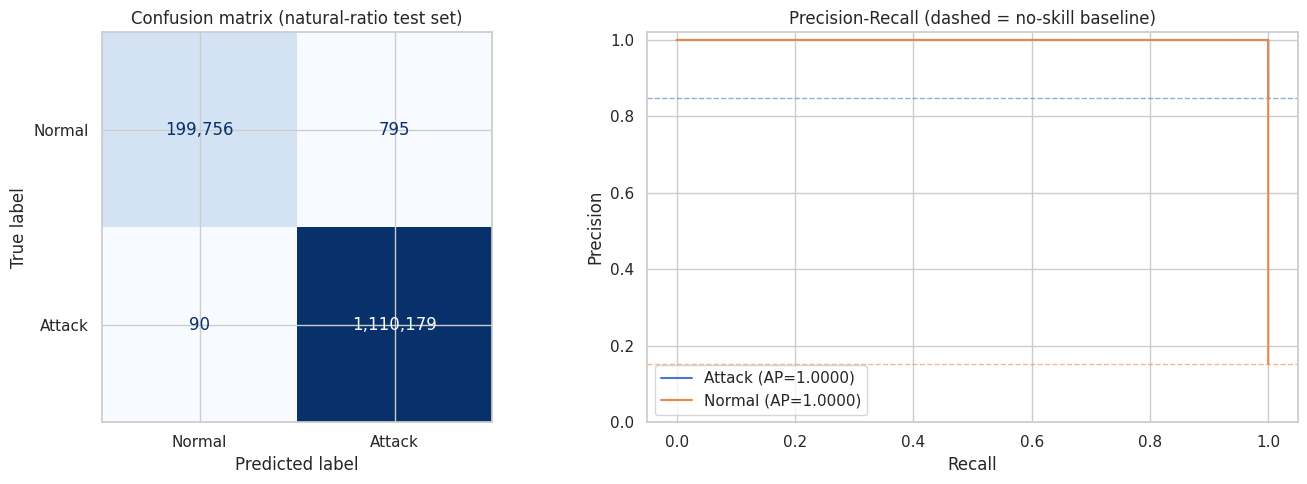

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
ConfusionMatrixDisplay(cm, display_labels=["Normal", "Attack"]).plot(
    cmap="Blues", values_format=",d", ax=axes[0], colorbar=False
)
axes[0].set_title("Confusion matrix (natural-ratio test set)")

for positive, name, score in ((1, "Attack", p_attack), (0, "Normal", 1.0 - p_attack)):
    yb = (y_test == positive).astype(int)
    prec, rec, _ = precision_recall_curve(yb, score)
    ap = metrics_full["ap_attack"] if positive == 1 else metrics_full["ap_normal"]
    line, = axes[1].plot(rec, prec, label=f"{name} (AP={ap:.4f})")
    axes[1].axhline(yb.mean(), ls="--", lw=1, color=line.get_color(), alpha=0.6)

axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall (dashed = no-skill baseline)")
axes[1].legend(loc="lower left")
axes[1].set_ylim(0, 1.02)
plt.tight_layout()
plt.show()

## 19. Feature importances

If one feature dominates, the score is really that feature's score. Worth knowing before
believing any headline number.

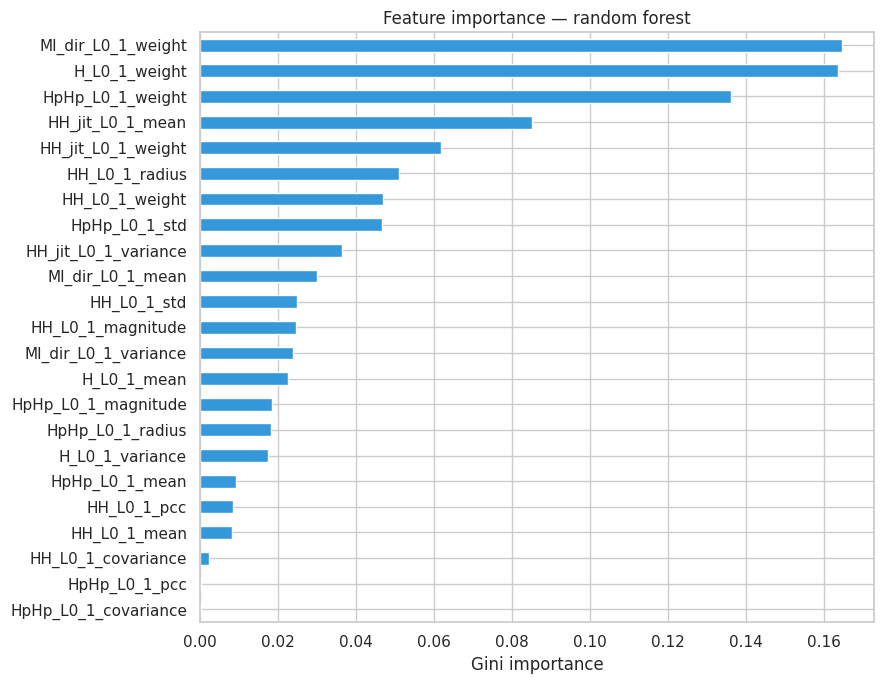

MI_dir_L0_1_weight    0.1645
H_L0_1_weight         0.1635
HpHp_L0_1_weight      0.1361
HH_jit_L0_1_mean      0.0850
HH_jit_L0_1_weight    0.0618
HH_L0_1_radius        0.0510
HH_L0_1_weight        0.0470
HpHp_L0_1_std         0.0466

Top feature carries 16.5% of total importance.


In [27]:
importances = (
    pd.Series(rf.feature_importances_, index=FEATURE_COLS)
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(9, 7))
importances.iloc[::-1].plot.barh(ax=ax, color="#3498db")
ax.set_xlabel("Gini importance")
ax.set_title("Feature importance — random forest")
plt.tight_layout()
plt.show()

print(importances.head(8).round(4).to_string())
print(f"\nTop feature carries {importances.iloc[0]:.1%} of total importance.")

## 21. Save the model and predictions

The saved bundle carries the **feature order** and the **label polarity** alongside the
estimator. Without those two the model is unusable: the streaming job would have no way to
know which column goes in which position, or that class 1 means attack while the raw
`label` column means the opposite.

In [35]:
bundle = {
    "model": rf,
    "feature_cols": FEATURE_COLS,          # order matters at inference time
    "attack_label": ATTACK_LABEL,          # value of raw `label` meaning attack
    "normal_label": NORMAL_LABEL,
    "target": "is_attack",                 # 1 = attack, regardless of raw label polarity
    "test_devices": test_devices,
    "train_ratio": f"{n_attack / n_normal:.2f}:1 attack:normal",
    "seed": SEED,
    "metrics": metrics_full,
}

model_path = MODEL_DIR / "random_forest.joblib"
joblib.dump(bundle, model_path, compress=3)
print(f"Model bundle -> {model_path}  ({model_path.stat().st_size / 1e6:.1f} MB)")

with open(MODEL_DIR / "model_card.json", "w") as f:
    json.dump({k: v for k, v in bundle.items() if k != "model"}, f, indent=2, default=str)
print(f"Model card   -> {MODEL_DIR / 'model_card.json'}")

Model bundle -> /kaggle/working/models/random_forest.joblib  (0.7 MB)
Model card   -> /kaggle/working/models/model_card.json


In [36]:
predictions = test_df[["is_attack"]].copy()
predictions["predicted"] = y_pred
predictions["p_attack"] = p_attack
predictions["correct"] = predictions["is_attack"] == predictions["predicted"]
predictions["Device_Name"] = training_df.loc[test_df.index, "Device_Name"]

pred_path = PRED_DIR / "test_predictions.parquet"
predictions.to_parquet(pred_path, index=False)
print(f"Predictions  -> {pred_path}  ({len(predictions):,} rows)")

print("\nPer-device accuracy on the held-out devices:")
print(predictions.groupby("Device_Name")["correct"].agg(["size", "mean"]).round(4).to_string())

Predictions  -> /kaggle/working/predictions/test_predictions.parquet  (1,310,820 rows)

Per-device accuracy on the held-out devices:
                                 size    mean
Device_Name                                  
Ennio_Doorbell                 285850  0.9999
Philips_B120N10_Baby_Monitor  1024970  0.9992


### Reload check

A saved model that cannot be reloaded is not saved. This reproduces the headline metric
from disk, in the same way the streaming job will load it.

In [37]:
reloaded = joblib.load(model_path)
X_check = test_df[reloaded["feature_cols"]].to_numpy(dtype=np.float32)
check_idx = list(reloaded["model"].classes_).index(1)
check_ap = average_precision_score(1 - y_test, 1.0 - reloaded["model"].predict_proba(X_check)[:, check_idx])

print(f"AP (Normal) from reloaded model: {check_ap:.4f}")
print(f"AP (Normal) from in-memory model: {metrics_full['ap_normal']:.4f}")
print("Match:", np.isclose(check_ap, metrics_full["ap_normal"]))

AP (Normal) from reloaded model: 1.0000
AP (Normal) from in-memory model: 1.0000
Match: True
